In [17]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()

# Find the repository directory containing insulators/__init__.py
while not (repo_root / "insulators" / "__init__.py").is_file():
    if repo_root == repo_root.parent:
        raise RuntimeError("Could not find the repository root")
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [18]:
import numpy as np
from matplotlib import pyplot as plt
from insulators.catenary import catenary, catenary_length
from insulators.line import line_between_points
from insulators.sag import catenary_sag_vertical
from insulators.plotting import catenary_plot_full
from insulators.th_solver import Th_for_target_sag
from insulators.attachment_solver import get_attachment_points_for_Th
from insulators.span_solver import solve_span_for_target_sag
from insulators.plotting import catenary_plot_with_insulators
from insulators.equation_9 import equation_9_sag, equation_9_tension


In [19]:

# Input Constants 
# note: kg = kg-force (essentially)

w = 34.91           #N/m
G = 160 * 9.81      #N     
L = 2               #m
E = 110000          #N/mm2              #6.18e9          #kg/m2 
diatomi =400        #mm2                #5.27            #cm2

# Suspension points
A = (0, 100) 
B = (62, 100 + 1.25)      #(593.70, 100 + 131.65)    #(144.54, 100-6.64) #

# target horizontal tension/ target sag
Th = 7526.26            #N
target_Th = Th          #N
target_sag = 3.87       #m  
target_fe = 3.26        #m

#########################################
Th = 5058.88 N
C = (1.79, 99.12)
D = (60.24, 100.31)
theta_left = -0.46 rad
theta_right = -0.49 rad
sag = 3.87 m
outer converged = True
inner converged = True
#########################################
maximum sag = 3.87 m
x at maximum sag = 31.001 m
catenary y there = 96.76 m
fe = 3.2 m
line y there = 100.63 m
#########################################
Equation 9 sag from tension (7526.26 N) = 2.72 m
Equation 9 tension from target sag (3.87 m) = 5299.30 N
Equation 9 tension from target fe (3.26 m) = 6290.88 N
#########################################


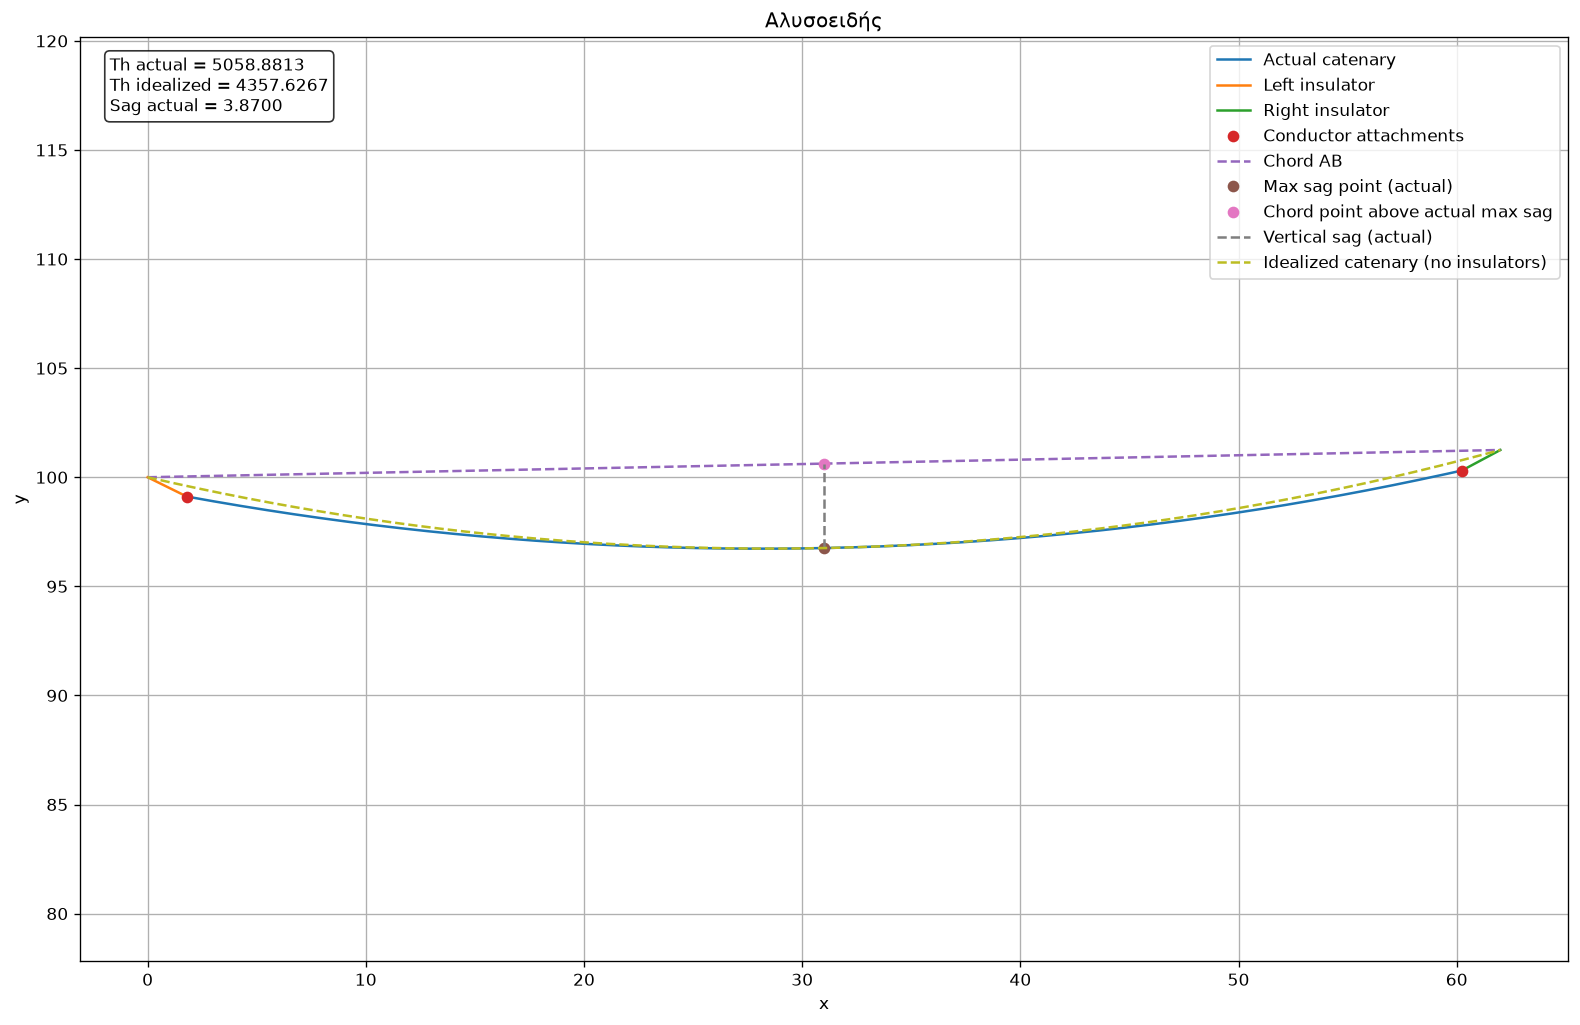

In [20]:

############### usage ######################

print("#########################################")

result = solve_span_for_target_sag(
    A=A,
    B=B,
    w=w,
    target_sag= target_sag,
    L_left=L,
    L_right=L,
    G_left=G,
    G_right=G,
)

Th = result["Th"]
C = result["C"]
D = result["D"]


print(f'Th = {result["Th"]:.2f} N')
print(f'C = ({result["C"][0]:.2f}, {result["C"][1]:.2f})')
print(f'D = ({result["D"][0]:.2f}, {result["D"][1]:.2f})')
print("theta_left =", result["theta_left"].round(2), "rad")
print("theta_right =", result["theta_right"].round(2), "rad")
print("sag =", result["sag"].round(2), "m")
print("outer converged =", result["converged"])
print("inner converged =", result["attachment_converged"])

print("#########################################")

#cat = catenary(A, B, w, Th)
cat = result["catenary"]
lineAB = line_between_points(A, B)
lineCD = line_between_points(C, D)

sag_info = catenary_sag_vertical(cat, lineAB)

print("maximum sag =", sag_info["sag_max"].round(2), "m")
print("x at maximum sag =", sag_info["x_sag"].round(3), "m")
print("catenary y there =", sag_info["y_curve"].round(2), "m")
print(f"fe = {100 - sag_info["y_curve"]:.2} m")
print("line y there =", sag_info["y_line"].round(2), "m")

print("#########################################")

# Actual horizontal conductor span between attachments C and D
#a0 = float(result["D"][0] - result["C"][0])
a0 = float(B[0] - A[0])

sag_eq9 = equation_9_sag(
    a0=a0,
    w=w,
    L_ins=L,
    G_ins=G,
    tension=target_Th,
)

tension_eq9 = equation_9_tension(
    a0=a0,
    w=w,
    L_ins=L,
    G_ins=G,
    target_sag=target_sag,
)

tension_eq9_fe = equation_9_tension(
    a0=a0,
    w=w,
    L_ins=L,
    G_ins=G,
    target_sag=target_fe,
)

print(f"Equation 9 sag from tension ({target_Th} N) = {sag_eq9:.2f} m")
print(f"Equation 9 tension from target sag ({target_sag} m) = {tension_eq9:.2f} N")
print(f"Equation 9 tension from target fe ({target_fe} m) = {tension_eq9_fe:.2f} N")


print("#########################################")

#catenary_plot_full(cat, lineAB)

catenary_plot_with_insulators(
    cat=result["catenary"],
    A=A,
    B=B,
    C=result["C"],
    D=result["D"],
    show_actual=True,
    show_supports=False,
    show_attachments=True,
    show_chord=True,
    show_low_point=False,
    show_sag=True,
    show_idealized=True,
    show_idealized_sag=False,
    annotate_tensions=True,
    only_idealized=False,
    w=w,
    title="Αλυσοειδής",
    #figsize=(18, 11),
)



In [21]:
from insulators.dxf_export import export_span_to_dxf

dxf_path = export_span_to_dxf(
    result=result,
    A=A,
    B=B,
    output_path="insulator_span.dxf",
    show_supports=True,
    show_attachments=True,
    show_chord=True,
    show_sag=True,
    show_idealized=True,
    show_idealized_sag=False,
    w=w,
    coordinate_precision=2,
)

print(dxf_path.resolve())

/workspaces/remigrated/insulators/insulator_span.dxf
